# IntRO-CAD - S2025
### Shorouk Aldeyarbi

In [ ]:
# Reproducibility
import numpy as np
import random

np.random.seed(42)
random.seed(42)

# Machine Learning Workflow
### RandomForest: https://www.datacamp.com/tutorial/random-forests-classifier-python
## Importing the libraries


In [115]:
pip install scikit-learn
pip install graphviz
# through the link: https://archive.ics.uci.edu/dataset/45/heart+disease 
pip install ucimlrepo

SyntaxError: invalid syntax (2623595544.py, line 1)

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

In [59]:
# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

## Importing Dataset: 
### via: https://archive.ics.uci.edu/dataset/45/heart+disease 


In [ ]:
pip install ucimlrepo

In [60]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 

# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 

# metadata 
print(heart_disease.metadata) 


# variable information 
print(heart_disease.variables) 

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [61]:
#Extract the row names to be a colnames :
col_names = heart_disease.variables['name'].tolist()
col_names

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'num']

In [62]:
dataset = pd.read_csv('processed.hungarian.data',header=None,names= col_names)
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160,331,0,0,94,1,2.5,?,?,?,1
290,54,0,3,130,294,0,1,100,1,0.0,2,?,?,1
291,56,1,4,155,342,1,0,150,1,3.0,2,?,?,1
292,58,0,2,180,393,0,0,110,1,1.0,2,?,7,1


## Cleaning DATA 

In [63]:
# Replace '?' with nan
dataset.replace('?', np.nan, inplace=True)

In [106]:
dataset.isna().sum()

age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64

In [64]:
# Split the data into features (X) and target (y)
X = dataset.drop(columns= ["slope", "ca", "thal", "num"])
y = dataset["num"]

In [65]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak
0,28,1,2,130,132,0,2,185,0,0.0
1,29,1,2,120,243,0,0,160,0,0.0
2,29,1,2,140,NaN,0,0,170,0,0.0
3,30,0,1,170,237,0,1,170,0,0.0
4,31,0,2,100,219,0,1,150,0,0.0
...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160,331,0,0,94,1,2.5
290,54,0,3,130,294,0,1,100,1,0.0
291,56,1,4,155,342,1,0,150,1,3.0
292,58,0,2,180,393,0,0,110,1,1.0


In [8]:
y

0      0
1      0
2      0
3      0
4      0
      ..
289    1
290    1
291    1
292    1
293    1
Name: num, Length: 294, dtype: int64

In [20]:
dataset['num'].value_counts()

num
0    188
1    106
Name: count, dtype: int64

# **1-**  RandomForest

## Split the Data into Training/Test Sets  

In [66]:
from sklearn.model_selection import train_test_split
X_trainRF, X_testRF, y_trainRF, y_testRF = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [67]:
rf = RandomForestClassifier()
rf.fit(X_trainRF, y_trainRF)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
y_predRF = rf.predict(X_testRF)

In [69]:
accuracy = accuracy_score(y_testRF, y_predRF)
print("Accuracy:", accuracy)

Accuracy: 0.8513513513513513


## Visualizing the Results

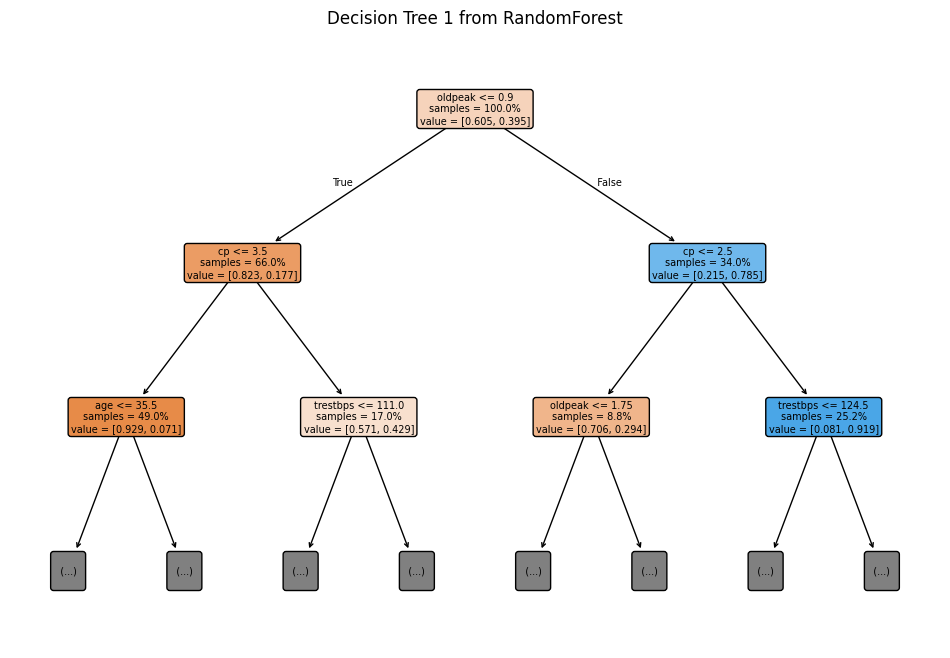

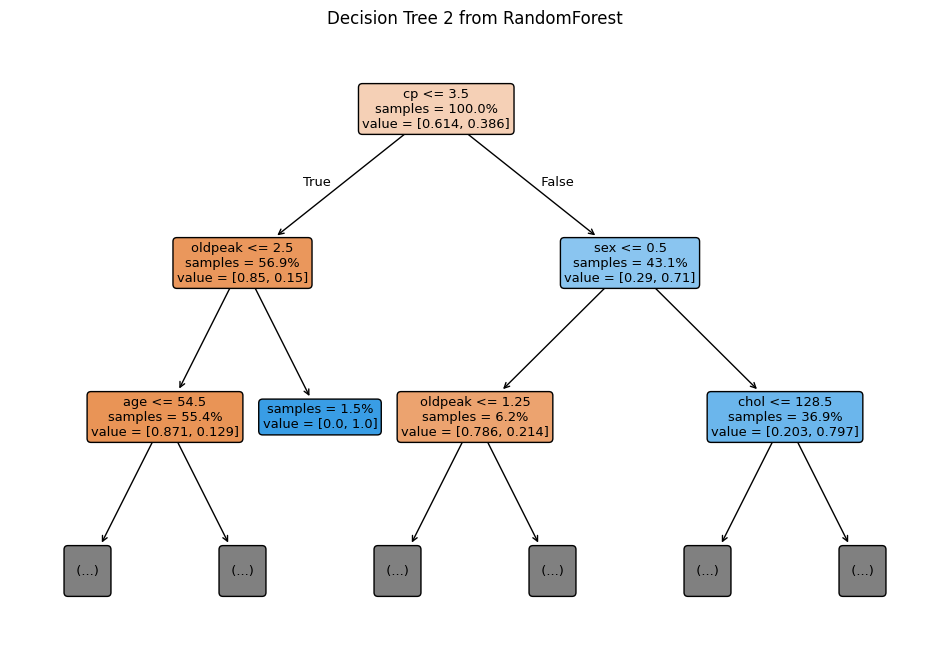

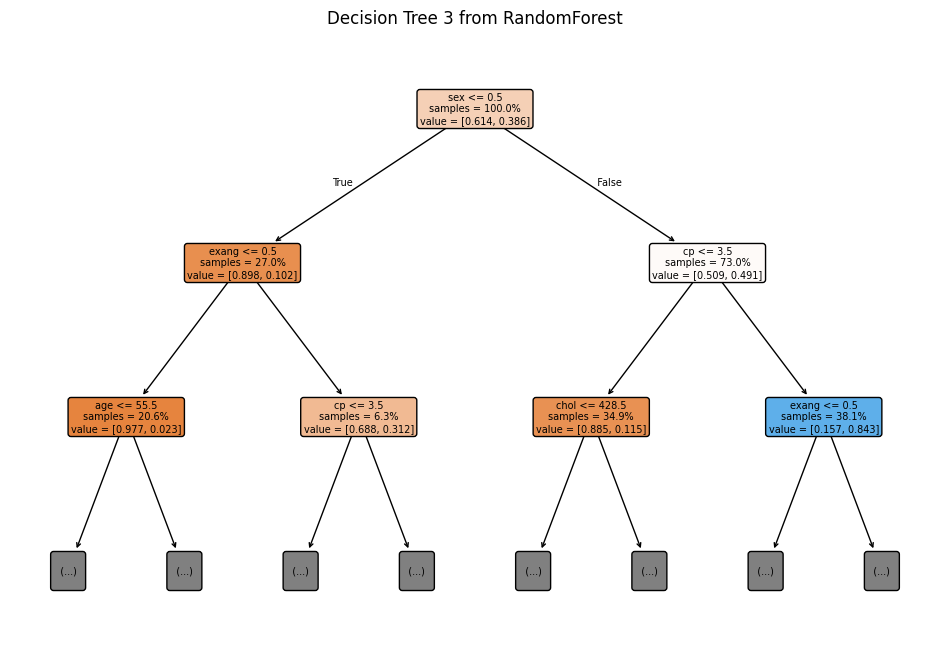

In [71]:
# Export the first three decision trees from the forest
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

for i in range(3):
    tree = rf.estimators_[i]  # Take one tree from the RandomForest
    plt.figure(figsize=(12, 8))
    plot_tree(
        tree,
        feature_names=X_trainRF.columns,
        filled=True,
        max_depth=2,
        impurity=False,
        proportion=True,
        rounded=True
    )
    plt.title(f"Decision Tree {i+1} from RandomForest")
    plt.show()


## Hyperparameter

In [72]:
param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

# Create a random forest classifier
rf = RandomForestClassifier()

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf, 
                                 param_distributions = param_dist, 
                                 n_iter=5, 
                                 cv=5)

# Fit the random search object to the data
rand_search.fit(X_trainRF, y_trainRF)

,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': <scipy.stats....001F2E20DB950>, 'n_estimators': <scipy.stats....001F2E6057ED0>}"
,n_iter,5
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [73]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'max_depth': 3, 'n_estimators': 217}


## RF Confusion Matrix

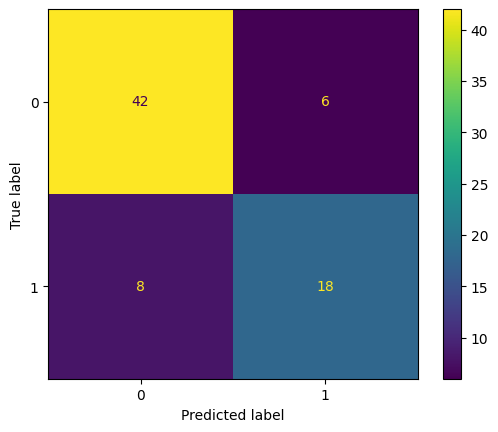

In [74]:
# Generate predictions with the best model
y_predRF = best_rf.predict(X_testRF)

# Create the confusion matrix
cm = confusion_matrix(y_testRF, y_predRF)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

### Best Feature in prediction

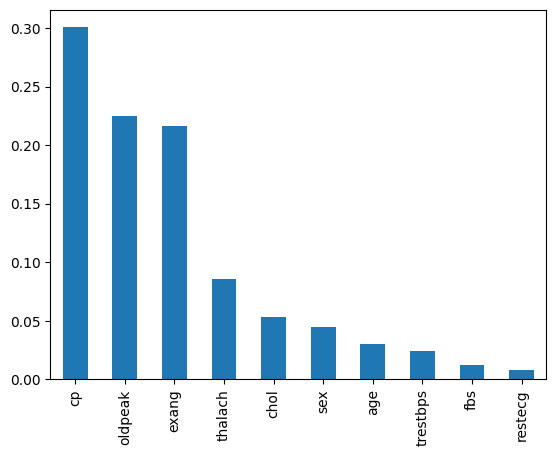

In [75]:
# Create a series containing feature importances from the model and feature names from the training data
feature_importances = pd.Series(best_rf.feature_importances_, index=X_trainRF.columns).sort_values(ascending=False)

# Plot a simple bar chart
feature_importances.plot.bar();

### RandomForest - ROC - : 

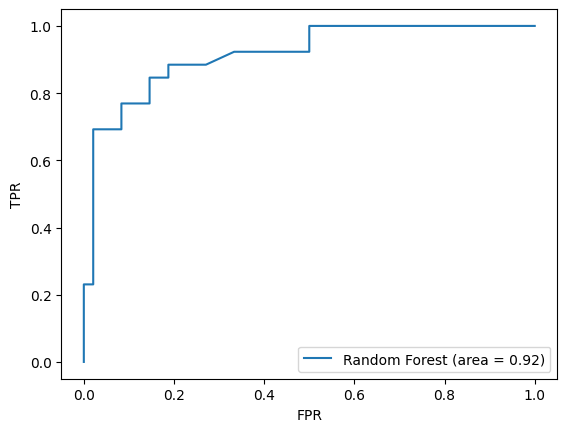

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
## FITTING: 
rf.fit(X_trainRF, y_trainRF)
y_probsRF = rf.predict_proba(X_testRF)[:, 1] 

logit_roc_auc = roc_auc_score(y_testRF, y_probsRF)
fpr, tpr, thresholds = roc_curve(y_testRF, y_probsRF)
plt.figure()
plt.plot(fpr, tpr, label='Random Forest (area = %0.2f)' % logit_roc_auc)
plt.legend(loc="lower right")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

# **2-** KNN

In [ ]:
from sklearn.model_selection import train_test_split
X_trainKNN, X_testKNN, y_trainKNN, y_testKNN = train_test_split(X, y, test_size = 0.25, random_state = 42)

### cleaning: 

In [79]:
from sklearn.impute import SimpleImputer

# Create an imputer (fill NaNs with mean value of each column)
imputer = SimpleImputer(strategy='median')

# Fit on training data and transform both train and test sets
X_trainKNN = imputer.fit_transform(X_trainKNN)
X_testKNN = imputer.transform(X_testKNN)


In [80]:
##Scalling for accuracy increasing: 
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_trainKNN = sc.fit_transform(X_trainKNN)
X_testKNN = sc.transform(X_testKNN)

In [81]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 3, metric = 'minkowski', p = 2)
classifier.fit(X_trainKNN, y_trainKNN)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [85]:
y_predKNN = classifier.predict(X_testKNN)


In [86]:
accuracy = accuracy_score(y_testKNN, y_predKNN)
precision = precision_score(y_testKNN, y_predKNN)
recall = recall_score(y_testKNN, y_predKNN)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.8918918918918919
Precision: 0.9583333333333334
Recall: 0.7666666666666667


## Prediction

In [87]:
import numpy as np
y_predKNN = classifier.predict(X_testKNN)
print(np.concatenate((y_predKNN.reshape(len(y_predKNN),1), y_testKNN.values.reshape(len(y_testKNN),1)), axis=1))


[[0 1]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]]


## Making the Confusion Matrix

In [88]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_testKNN, y_predKNN)
print(cm)
accuracy_score(y_testKNN, y_predKNN)


[[43  1]
 [ 7 23]]


0.8918918918918919

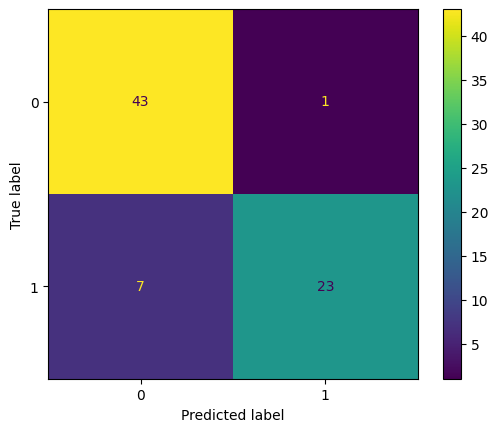

In [89]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot();

### KNN - ROC: 

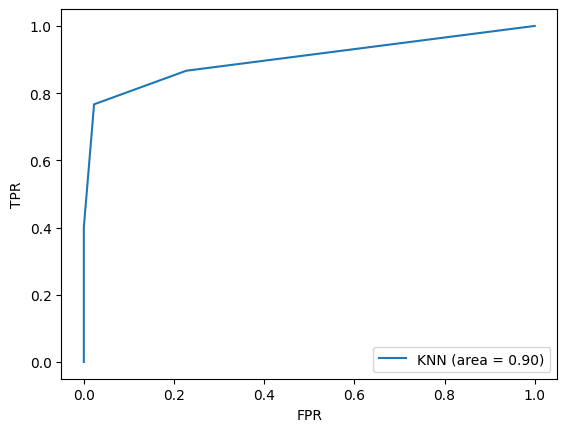

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

y_probsKNN = classifier.predict_proba(X_testKNN)[:, 1]
KNN_roc_auc = roc_auc_score(y_testKNN, y_probsKNN)
fpr, tpr, thresholds = roc_curve(y_testKNN, y_probsKNN)
plt.figure()
plt.plot(fpr, tpr, label='KNN (area = %0.2f)' % KNN_roc_auc)
plt.legend(loc="lower right")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

## **3-** Logistic- Regression
###        **REF: https://kejzlar.com/posts/logistic-python/

In [90]:
from sklearn.model_selection import train_test_split
X_trainLR, X_testLR, y_trainLR, y_testLR = train_test_split(X, y, test_size = 0.25, random_state = 42)

## Cleaning: 

In [93]:
from sklearn.impute import SimpleImputer

# Create an imputer (fill NaNs with mean value of each column)
imputer = SimpleImputer(strategy='median')

# Fit on training data and transform both train and test sets
X_trainLR = imputer.fit_transform(X_trainLR)
X_testLR = imputer.transform(X_testLR)

In [94]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(solver = 'liblinear', random_state = 0, max_iter=1000, penalty = 'l2')
logreg.fit(X_trainLR, y_trainLR)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [96]:
y_predLR = logreg.predict(X_testLR)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_testLR, y_testLR)))

Accuracy of logistic regression classifier on test set: 0.84


## LOG.REG: confusion_matrix

In [97]:
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_testLR, y_predLR)
print(confusion_matrix)
accuracy_score(y_testLR, y_predLR)

[[42  6]
 [ 6 20]]


0.8378378378378378

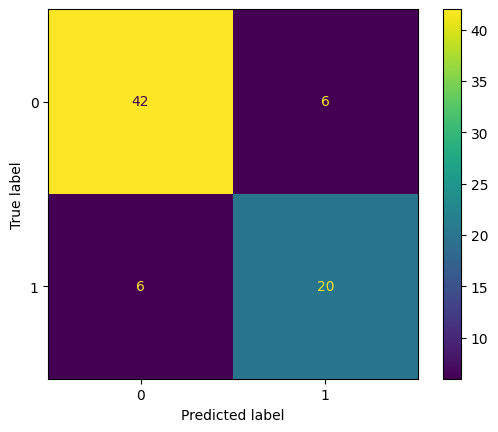

In [98]:
ConfusionMatrixDisplay(confusion_matrix).plot();

## L.R: ROC (BINARY)

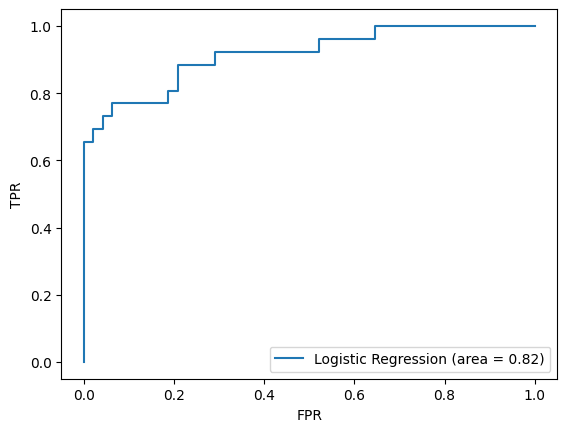

In [99]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

logit_roc_auc = roc_auc_score(y_testLR, logreg.predict(X_testLR))
fpr, tpr, thresholds = roc_curve(y_testLR, logreg.predict_proba(X_testLR)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.legend(loc="lower right")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()